In [1]:
import os
from os.path import expanduser
home = expanduser("~/")

import sys
# sys.path.insert(0, '/global/u2/x/xshuang/gigalens-xh-dev/src')

# import sys
conda_env = sys.path[1]
del sys.path[1]

import os
# sys.path.append(f'{os.environ['HOME']}/gigalens_personal/gigalens/src')
sys.path.append(home+'/gigalens'+'/src')
sys.path.append(conda_env)
sys.path.append(home+'/GIGALens-Code/')
print(sys.path)



srcdir = os.path.join(home, "gigalens/src/")


['', '/usr/lib/python312.zip', '/usr/lib/python3.12', '/usr/lib/python3.12/lib-dynload', '/usr/local/lib/python3.12/dist-packages', '__editable__.flax-0.10.6.finder.__path_hook__', '__editable__.jax_cuda12_pjrt-0.6.2.dev20250607.finder.__path_hook__', '__editable__.jax_cuda12_plugin-0.6.2.dev20250607.finder.__path_hook__', '__editable__.nsys_jax-0.1.dev1163+g4a8f06a.finder.__path_hook__', '/opt/pip/src', '/usr/lib/python3/dist-packages', '/global/homes/l/linusu//gigalens/src', '/global/homes/l/linusu/.conda/envs/gigalens_multinode_env/lib/python3.12/site-packages', '/global/homes/l/linusu//GIGALens-Code/']


In [3]:
import tensorflow_probability.substrates.jax as tfp

from gigalens.jax.inference import ModellingSequence
from gigalens.jax.model import ForwardProbModel, BackwardProbModel
from gigalens.model import PhysicalModel
from gigalens.jax.simulator import LensSimulator
from gigalens.simulator import SimulatorConfig
from gigalens.jax.profiles.light import sersic
from gigalens.jax.profiles.mass import epl, shear, tnfw

import jax
from jax import random
import numpy as np
import optax
from jax import numpy as jnp
from matplotlib import pyplot as plt
import optax
import corner
import yaml
import pickle
from helpers import *
import blackjax
import importlib
from alternate_inference.mclmc_alt import MCLMC
tfd = tfp.distributions

In [4]:

import gigalens
importlib.reload(gigalens)
from gigalens.jax.profiles.mass import tnfw_ellipse
import lenstronomy
from lenstronomy.Data.pixel_grid import PixelGrid
import functools
from typing import List, Dict

import jax
import jax.numpy as jnp
import numpy as np
from jax import jit
from jax import lax
from lenstronomy.Util.kernel_util import subgrid_kernel
from objax.constants import ConvPadding
from objax.functional import average_pool_2d
from gigalens.jax.simulator import LensSimulator
import gigalens.model
import gigalens.simulator
from helpers import *

In [4]:
save_dir = os.path.join(home, "GIGALens-Code/source_modeling/vela_sim_systems/")

In [5]:
import functools
class ImageBasedLight(gigalens.profile.LightProfile):
    _name = "IMAGEBASEDLIGHT"
    _params = []

    def __init__(self, image, image_pixel_scale, *args, **kwargs):
        super(ImageBasedLight, self).__init__(*args, **kwargs)
        if len(image.shape)!=2 and image.shape[0] != image.shape[1]:
            raise ValueError(f"Image must be square. Instead it is of shape {image.shape}")
        
        self.source_img = image
        num_pix = self.source_img.shape[0]
        self.image_pixel_scale = image_pixel_scale

        # self.transform_pix2angle = np.eye(2) * self.image_pixel_scale

        # lo = np.arange(0, num_pix, dtype=np.float32)
        # lo = np.min(lo - np.mean(lo))

        # ra_at_xy_0, dec_at_xy_0 = np.squeeze((self.transform_pix2angle @ ([[lo], [lo]])))

        # pixel_grid = PixelGrid(
        #     num_pix, num_pix,
        #     self.transform_pix2angle, ra_at_xy_0, dec_at_xy_0,
        # )
        # img_x, img_y = (
        #     pixel_grid._x_grid.astype(np.float32),
        #     pixel_grid._y_grid.astype(np.float32),
        # )
        # print(f"From {np.min(img_x)} to {np.max(img_x)}")
        half_extent = (num_pix - 1) / 2.0 * self.image_pixel_scale
        x_1d = np.linspace(-half_extent, half_extent, num_pix).astype(np.float32)
        y_1d = np.linspace(-half_extent, half_extent, num_pix).astype(np.float32)
        self.interpolator = jax.scipy.interpolate.RegularGridInterpolator(
            (x_1d, y_1d), self.source_img, method='linear', fill_value=0.0
        )
        # self.interpolator = jax.scipy.interpolate.RegularGridInterpolator((img_x, img_y), self.source_img, method='linear', fill_value=0.0)

    # @functools.partial(jax.jit, static_argnums=(0,))
    def light(self, x, y):
        points = jnp.stack([x, y], axis=-1)
        return self.interpolator(points)

In [6]:
import numpy as np, json
source_plane_dir = "dm_subhalo_complex/vela10_cam00_a0.500_f814w/"
source_img_nJy = np.load(os.path.join(source_plane_dir, "source_image.npy"))
psf    = np.load(os.path.join(source_plane_dir, "psf.npy"))
with open(os.path.join(source_plane_dir, "metadata.json")) as f:
    meta = json.load(f)


source_img_pixel_scale = meta['source_pixel_scale_arcsec']
delta_pix = meta['instrument_pixel_scale_arcsec']
num_pix = 200

SB_nJy_per_arcsec2 = source_img_nJy / (source_img_pixel_scale**2)

SB_cps_per_arcsec2 = SB_nJy_per_arcsec2* 1e-9 /meta["photfnu_Jy"]
# count_rate = image_nJy * 1e-9 / meta["photfnu_Jy"]
# total_flux_Jy = np.sum(source_img_nJy) *1e-9
# total_cps = total_flux_Jy/ meta["photfnu_Jy"]
sim_config = SimulatorConfig(delta_pix=delta_pix, num_pix=num_pix, supersample=1, kernel=psf)

In [7]:
import lenstronomy.Util.image_util as image_util
def noise_images(imgs, exp_time=100, background_rms=0.2):
    noised_images = []
    #* Add noise
    for lens_img in imgs:
        poisson = image_util.add_poisson(lens_img, exp_time=exp_time)
        bkg = image_util.add_background(lens_img, sigma_bkd=background_rms) # gaussian, mean is 0
        noised_images.append(lens_img + poisson + bkg) 

    return noised_images

In [8]:
vela_light = ImageBasedLight(SB_cps_per_arcsec2, source_img_pixel_scale)
phys_model = PhysicalModel([], [], [vela_light])
lens_sim = LensSimulator(phys_model, sim_config, bs=1)

sim_src = lens_sim.simulate([[], [{},]]) # Choose 1st archetypal system
background_rms = 0.002
exp_time = 2000
sim_src_noised = noise_images([sim_src], exp_time=exp_time, background_rms=background_rms)[0]

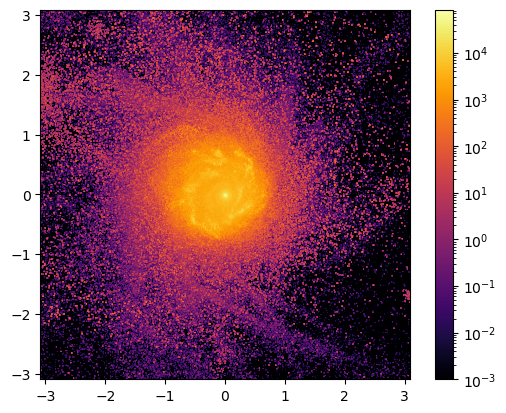

In [9]:
n = SB_nJy_per_arcsec2.shape[0]
dpx = source_img_pixel_scale
extent = [-n*dpx/2, n*dpx/2, -n*dpx/2, n*dpx/2]
plt.imshow(SB_nJy_per_arcsec2, norm = matplotlib.colors.LogNorm(vmin=1e-3,clip=True), extent=extent,cmap='inferno')
plt.colorbar()
plt.show()

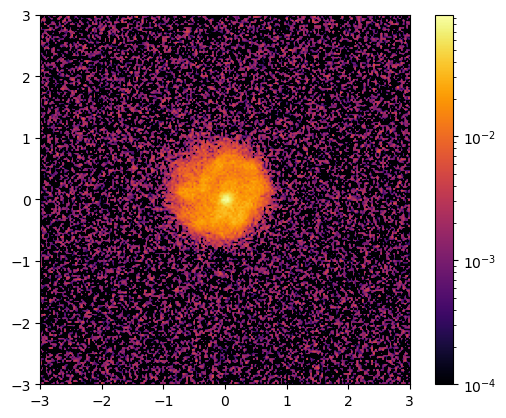

In [10]:
n = num_pix
dpx = delta_pix
extent = [-n*dpx/2, n*dpx/2, -n*dpx/2, n*dpx/2]
plt.imshow(sim_src_noised, norm = matplotlib.colors.LogNorm(vmin=1e-4, clip=True), extent=extent,cmap='inferno')
plt.colorbar()
plt.show()

# np.save(os.path.join(save_dir, "src_img"), sim_src_noised)

In [11]:


import numpy as np
from scipy.optimize import brentq
from astropy.cosmology import FlatLambdaCDM
from lenstronomy.Cosmo.lens_cosmo import LensCosmo
from lenstronomy.LensModel.Profiles.nfw import NFW

def get_nfw_einstein_radius_lenstronomy(M200, c, z_lens, z_source, H0=70, Om0=0.3):
    """
    Calculates the NFW Einstein radius using lenstronomy components.
    
    Parameters:
    M200 : float - Halo mass (M_200) in M_sun.
    c    : float - Concentration parameter.
    z_lens : float - Redshift of the lens.
    z_source : float - Redshift of the source.
    """
    # 1. Initialize Cosmology and LensCosmo
    cosmo = FlatLambdaCDM(H0=H0, Om0=Om0)
    lens_cosmo = LensCosmo(z_lens=z_lens, z_source=z_source, cosmo=cosmo)
    
    # 2. Convert Physical NFW (M, c) to Angular NFW (Rs_angle, alpha_Rs)
    # Rs_angle: scale radius in arcseconds
    # alpha_Rs: deflection angle at the scale radius
    Rs_angle, alpha_Rs = lens_cosmo.nfw_physical2angle(M=M200, c=c)
    
    # 3. Define the NFW profile instance
    nfw_profile = NFW()

    # 4. Solve the lens equation: alpha(theta) - theta = 0
    # Note: For a spherical profile, alpha is only in the radial direction.
    def lens_equation(theta):
        # We calculate the deflection angle at radius 'theta'
        # derivatives() returns (f_x, f_y) - we just need the x-component for 1D
        alpha_theta, _ = nfw_profile.derivatives(x=theta, y=0, Rs=Rs_angle, alpha_Rs=alpha_Rs)
        return alpha_theta - theta

    try:
        # Search for a root (Einstein Radius) between a tiny radius and a large one
        # Typical cluster theta_E is < 100", so we search up to 50 * Rs_angle
        theta_E = brentq(lens_equation, 1e-9, Rs_angle * 50)
        return theta_E
    except (ValueError, RuntimeError):
        # Returns 0 if no solution exists (halo too diffuse to be critical)
        return 0.0


M = 1e10 #1e10
c = 10.0 # 10.0
z_lens = 0.3
z_source = 1.0

cosmo = FlatLambdaCDM(H0=70, Om0=0.3)
lens_cos = LensCosmo(z_lens=z_lens, z_source=z_source, cosmo=cosmo)
Rs_angle, alpha_Rs = lens_cos.nfw_physical2angle(M, c)
print(f"Rs_angle: {Rs_angle}, alpha_Rs: {alpha_Rs}")

theta_E = get_nfw_einstein_radius_lenstronomy(M, c, z_lens, z_source)
print(f"Einstein Radius: {theta_E} arcsec")

Rs_angle: 0.900722533864909, alpha_Rs: 0.012953730251947434
Einstein Radius: 5.161327757540501e-07 arcsec


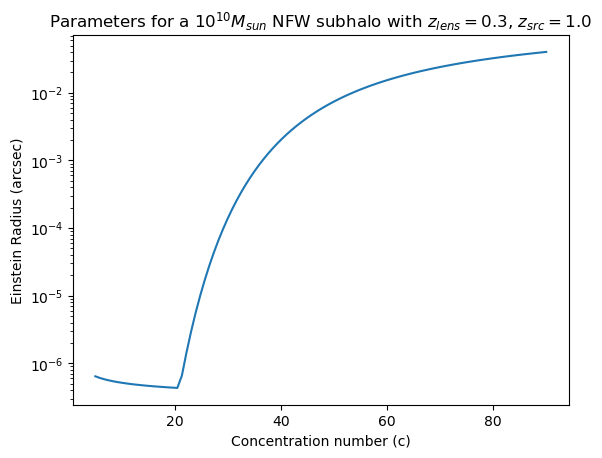

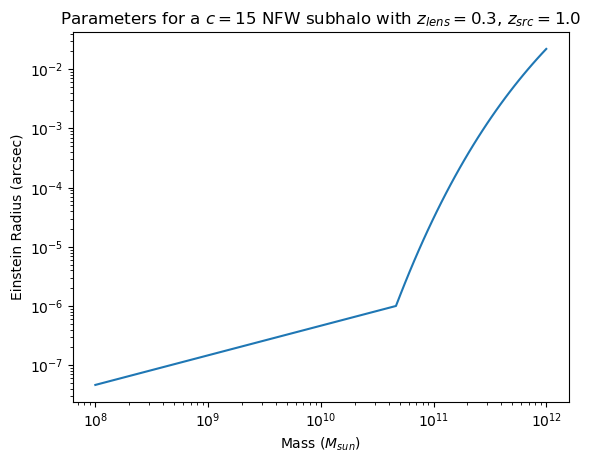

In [12]:
def theta_E_physical(M_in, c_in):
    cosmo = FlatLambdaCDM(H0=70, Om0=0.3)
    lens_cos = LensCosmo(z_lens=z_lens, z_source=z_source, cosmo=cosmo)
    Rs_angle, alpha_Rs = lens_cos.nfw_physical2angle(M_in, c_in)
    return einstein_radius(Rs_angle, alpha_Rs)

def einstein_radius(Rs, alpha):
    # lens_model_list = ['TNFW']
    # kwargs_lens = [{
    #     'Rs': Rs,
    #     'alpha_Rs': alpha,
    #     'r_trunc': 100,
    #     'center_x': 0,
    #     'center_y': 0
    # }]
    
    # lensModel = LensModel(lens_model_list=lens_model_list)
    
    # def einstein_eq(r):
    #     # x-component of the deflection at (r, 0) 
    #     alpha = lensModel.alpha(r, 0, kwargs=kwargs_lens)[0]  # extract the x-component of deflection
    #     return r - alpha
    nfw_profile = NFW()
    def lens_equation(theta):
        # We calculate the deflection angle at radius 'theta'
        # derivatives() returns (f_x, f_y) - we just need the x-component for 1D
        alpha_theta, _ = nfw_profile.derivatives(x=theta, y=0, Rs=Rs, alpha_Rs=alpha)
        return alpha_theta - theta
    
    # solve for r such that einstein_eq(r) = 0.
    r_min, r_max = 1e-20, 5.0  # change limits as needed, sometime it'll error
    r_einstein = brentq(lens_equation, r_min, 5*Rs)
    return r_einstein

M_arr = 1e10 * jnp.ones(100)
c_arr = jnp.linspace(5, 90, 100)
theta_E_vec = np.vectorize(theta_E_physical)
plt.plot(c_arr, theta_E_vec(M_arr, c_arr))
plt.xlabel("Concentration number (c)")
plt.ylabel("Einstein Radius (arcsec)")
plt.title(rf"Parameters for a $10^{{10}} M_{{sun}}$ NFW subhalo with $z_{{lens}}=0.3$, $z_{{src}}=1.0$")
plt.yscale('log')
plt.show()

M_arr = jnp.logspace(8, 12, 100) #1e8 to 1e12
c_arr = 15.0 * jnp.ones(100)
theta_E_vec = np.vectorize(theta_E_physical)
plt.plot(M_arr, theta_E_vec(M_arr, c_arr))
plt.xlabel("Mass ($M_{{sun}})$")
plt.ylabel("Einstein Radius (arcsec)")
plt.title(rf"Parameters for a $c=15$ NFW subhalo with $z_{{lens}}=0.3$, $z_{{src}}=1.0$")
plt.yscale('log')
plt.xscale('log')
plt.show()
# print("Einstein radius:", r_einstein)

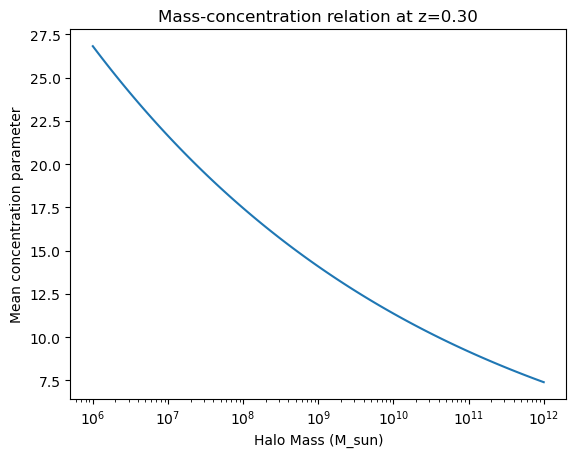

In [35]:
import jax
import jax.numpy as jnp
from tensorflow_probability.substrates import jax as tfp

tfd = tfp.distributions


def mean_concentration(
    m200_msun,
    z,
    *,
    h=0.6777,
    mdef="200c",
):
    """Dutton & Maccio (2014) field-halo c(M,z) relation.

    Source:
      Dutton & Maccio 2014, MNRAS 441, 3359
      https://arxiv.org/abs/1402.7073

    Notes:
      - calibrated for Planck13 cosmology
      - input/output for NFW concentration
      - mass is interpreted in Msun here and converted internally to Msun/h
    """
    m_h = m200_msun * h

    if mdef == "200c":
        a = 0.520 + (0.905 - 0.520) * jnp.exp(-0.617 * z**1.21)
        b = -0.101 + 0.026 * z
    elif mdef == "vir":
        a = 0.537 + (1.025 - 0.537) * jnp.exp(-0.718 * z**1.08)
        b = -0.097 + 0.024 * z
    else:
        raise ValueError("mdef must be '200c' or 'vir'")

    log10c = a + b * jnp.log10(m_h / 1.0e12)
    return 10.0 ** log10c


class BoundedPowerLaw(tfd.Distribution):
    """p(x) propto x^{-alpha} on [low, high], for alpha != 1."""

    def __init__(self, alpha, low, high, validate_args=False, name="BoundedPowerLaw"):
        parameters = dict(locals())
        self._alpha = jnp.asarray(alpha)
        self._low = jnp.asarray(low)
        self._high = jnp.asarray(high)
        super().__init__(
            dtype=self._low.dtype,
            reparameterization_type=tfd.FULLY_REPARAMETERIZED,
            validate_args=validate_args,
            allow_nan_stats=False,
            parameters=parameters,
            name=name,
        )

    def _event_shape(self):
        return tfp.tf2jax.TensorShape([])

    def _event_shape_tensor(self):
        return jnp.array([], dtype=jnp.int32)

    def _batch_shape_tensor(self):
        return jnp.broadcast_shapes(
            jnp.shape(self._alpha), jnp.shape(self._low), jnp.shape(self._high)
        )

    def _batch_shape(self):
        return tfp.tf2jax.TensorShape(self._batch_shape_tensor())

    def _sample_n(self, n, seed=None):
        u = jax.random.uniform(
            seed,
            shape=(n,) + self.batch_shape,
            minval=0.0,
            maxval=1.0,
            dtype=self.dtype,
        )
        a = 1.0 - self._alpha
        low_a = self._low ** a
        high_a = self._high ** a
        return (low_a + u * (high_a - low_a)) ** (1.0 / a)

    def _log_prob(self, x):
        a = self._alpha
        low = self._low
        high = self._high
        norm = (1.0 - a) / (high ** (1.0 - a) - low ** (1.0 - a))
        logp = jnp.log(norm) - a * jnp.log(x)
        in_support = (x >= low) & (x <= high)
        return jnp.where(in_support, logp, -jnp.inf)


class TruncatedLogNormal(tfd.Distribution):
    """LogNormal truncated to [low, high]."""

    def __init__(self, loc, scale, low, high, validate_args=False, name="TruncatedLogNormal"):
        parameters = dict(locals())
        self._loc = jnp.asarray(loc)
        self._scale = jnp.asarray(scale)
        self._low = jnp.asarray(low)
        self._high = jnp.asarray(high)

        self._base = tfd.Normal(loc=self._loc, scale=self._scale)
        self._log_low = jnp.log(self._low)
        self._log_high = jnp.log(self._high)
        self._z = self._base.cdf(self._log_high) - self._base.cdf(self._log_low)

        super().__init__(
            dtype=self._loc.dtype,
            reparameterization_type=tfd.FULLY_REPARAMETERIZED,
            validate_args=validate_args,
            allow_nan_stats=False,
            parameters=parameters,
            name=name,
        )

    def _event_shape(self):
        return tfp.tf2jax.TensorShape([])

    def _event_shape_tensor(self):
        return jnp.array([], dtype=jnp.int32)

    def _batch_shape_tensor(self):
        return jnp.broadcast_shapes(
            jnp.shape(self._loc),
            jnp.shape(self._scale),
            jnp.shape(self._low),
            jnp.shape(self._high),
        )

    def _batch_shape(self):
        return tfp.tf2jax.TensorShape(self._batch_shape_tensor())

    def _sample_n(self, n, seed=None):
        u = jax.random.uniform(
            seed,
            shape=(n,) + self.batch_shape,
            minval=0.0,
            maxval=1.0,
            dtype=self.dtype,
        )
        p = self._base.cdf(self._log_low) + u * self._z
        y = self._base.quantile(p)
        return jnp.exp(y)

    def _log_prob(self, x):
        logx = jnp.log(x)
        log_pdf = self._base.log_prob(logx) - logx - jnp.log(self._z)
        in_support = (x >= self._low) & (x <= self._high)
        return jnp.where(in_support, log_pdf, -jnp.inf)


def make_subhalo_mass_concentration_prior(
    *,
    z_lens,
    m_min=1e6,
    m_max=1e10,
    alpha=1.9,
    sigma_log10c=0.12,
    c_min=2.0,
    c_max=80.0,
    h=0.6777,
    mdef="200c",
):
    sigma_lnc = sigma_log10c * jnp.log(10.0)

    return tfd.JointDistributionNamedAutoBatched(
        {
            "m200": BoundedPowerLaw(alpha=alpha, low=m_min, high=m_max),
            "c200": lambda m200: TruncatedLogNormal(
                loc=jnp.log(mean_concentration(m200, z_lens, h=h, mdef=mdef)),
                scale=sigma_lnc,
                low=c_min,
                high=c_max,
            ),
        }
    )

def logx_hist(ax, data,bins=50):
    start, stop = np.log10(min(data)), np.log10(max(data))
    bins = np.logspace(start, stop, bins) 
    ax.hist(data, bins=bins, density=True)
    ax.set_xscale('log')

m_c_prior = make_subhalo_mass_concentration_prior(
    z_lens=z_lens,
    m_min=1e7,
    m_max=1e10,
)
samples = m_c_prior.sample(10000, seed=jax.random.PRNGKey(0))
M_samples = samples['m200']
c_samples = samples['c200']

dummy_M = jnp.logspace(6, 12, 100) 
plt.plot(dummy_M, mean_concentration(dummy_M, z_lens, h=0.6777, mdef='200c'))
plt.xscale('log')
plt.ylabel('Mean concentration parameter')
plt.title(f"Mass-concentration relation at z={z_lens:.2f}")
plt.xlabel('Halo Mass (M_sun)')
plt.show()

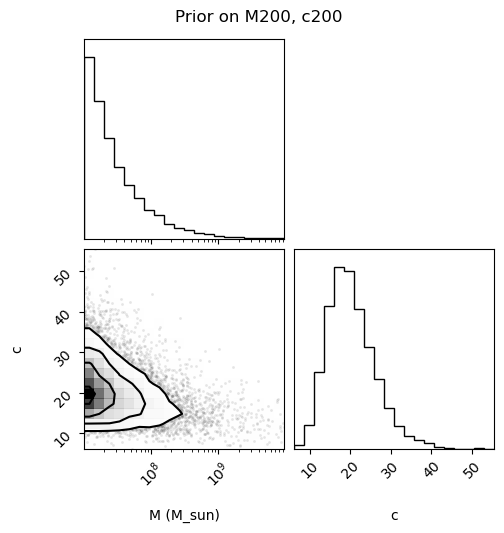

In [37]:
fig=corner.corner(np.vstack(list(samples.values())).T, labels=["M (M_sun)", "c"], axes_scale=['log', 'linear'])
fig.suptitle("Prior on M200, c200")
plt.show()

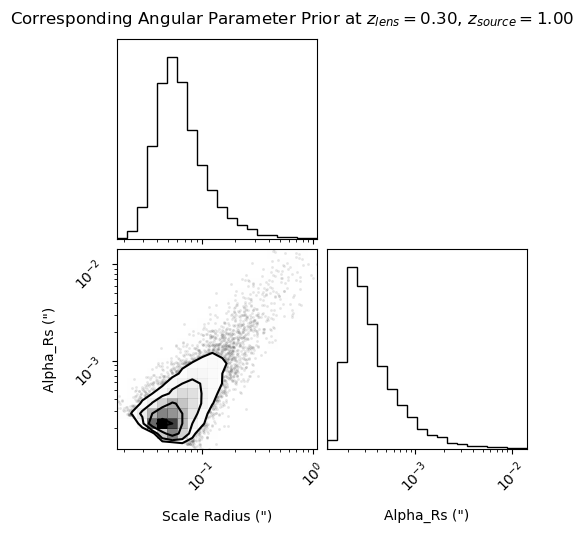

In [42]:
cosmo = FlatLambdaCDM(H0=67.0, Om0=0.3)
lens_cos = LensCosmo(z_lens=z_lens, z_source=z_source, cosmo=cosmo)
angular_conv = lambda M_in, c_in : lens_cos.nfw_physical2angle(M_in, c_in)
angular_conv_vectorize = np.vectorize(angular_conv)
Rs_smp, alpha_smp = angular_conv_vectorize(M_samples, c_samples)

from scipy.stats import lognorm

Rs_spread, _, Rs_mu = lognorm.fit(Rs_smp, floc=0)
alpha_spread, _, alpha_mu = lognorm.fit(alpha_smp, floc=0)

# print(mu)

# fig, (ax1, ax2) = plt.subplots(1, 2)
# fig.set_size_inches(10, 5)
# ax1.hist(Rs_smp, bins=20, density=True)
# dummy_x = np.linspace(np.min(Rs_smp), np.max(Rs_smp), 100)
# ax1.plot(dummy_x, lognorm.pdf(dummy_x, Rs_spread, 0, Rs_mu), label=f"LogNorm({Rs_mu:.4f}, {Rs_spread:.2f})")
# ax1.legend()
# ax1.set_xlabel("Rs (arcsec)")

# ax2.hist(alpha_smp, bins=20, density=True)
# dummy_x = np.linspace(np.min(alpha_smp), np.max(alpha_smp), 100)
# ax2.plot(dummy_x, lognorm.pdf(dummy_x, alpha_spread, 0, alpha_mu), label=f"LogNorm({alpha_mu:.4f}, {alpha_spread:.2f})")
# ax2.legend()
# ax2.set_xlabel("alpha_Rs (arcsec)")
# plt.show()



fig=corner.corner(np.vstack([Rs_smp, alpha_smp]).T, labels=["Scale Radius (\")", "Alpha_Rs (\")"], axes_scale=['log', 'log'])
fig.suptitle(f"Corresponding Angular Parameter Prior at $z_{{lens}}={z_lens:.2f}$, $z_{{source}}={z_source:.2f}$")
plt.show()

In [43]:


import lenstronomy.Util.image_util as image_util




halo_x, halo_y = 1.3, -0.7
true_params = ([
    {'theta_E': np.array([1.43,]), 
     'gamma': np.array([2.1,]), 
     'e1': np.array([0,]), 
     'e2': np.array([0.03,]), 
     'center_x': np.array([0.,]), 
     'center_y': np.array([0.,])},
    

    {'Rs': np.array([Rs_angle,]),
     'alpha_Rs': np.array([alpha_Rs,]), 
     'r_trunc': np.array([100.0,]), 
     'e1': np.array([0.,]), 
     'e2': np.array([0.,]), 
     'center_x': np.array([halo_x,]), 
     'center_y': np.array([halo_y,]),},
    
    {'gamma1': np.array([0,]), 
     'gamma2': np.array([0.16,])}
    
], [
    {'R_sersic': np.array([0.91,]), 
     'n_sersic': np.array([1.5,]), 
     'e1': np.array([0,]), 
     'e2': np.array([0.169,]), 
     'center_x': np.array([0.,]), 
     'center_y': np.array([0.,]), 
     'Ie': np.array([80,])},
   ],
    
    [
        {}
    ])

def noise_images(imgs, exp_time=100, background_rms=0.2):
    noised_images = []
    #* Add noise
    for lens_img in imgs:
        poisson = image_util.add_poisson(lens_img, exp_time=exp_time)
        bkg = image_util.add_background(lens_img, sigma_bkd=background_rms) # gaussian, mean is 0
        noised_images.append(lens_img + poisson + bkg) 

    return noised_images

#epl.EPL(50), 
phys_model_real = PhysicalModel([epl.EPL(50), tnfw_ellipse.TNFW_Ellipse(), shear.Shear()], [sersic.SersicEllipse(use_lstsq=False),], [vela_light])
lens_sim_real = LensSimulator(phys_model_real, sim_config, bs=1)

sim_lens = lens_sim_real.simulate(true_params) # Choose 1st archetypal system
background_rms = 0.002
exp_time = 2000
sim_lens_noised = noise_images([sim_lens], exp_time=exp_time, background_rms=background_rms)[0]
noise_map = get_noise_image(sim_lens, background_rms, exp_time)
# np.save(os.path.join(save_dir, "lens_img"), sim_lens_noised)
# import pickle
# with open(os.path.join(save_dir, "true_params"), 'wb') as file_handle:
#     pickle.dump(true_params, file_handle)

In [45]:
phys_model_no_halo = PhysicalModel([epl.EPL(50),shear.Shear()], [sersic.SersicEllipse(use_lstsq=False)], [vela_light])
lens_sim_no_halo = LensSimulator(phys_model_no_halo, sim_config, bs=1)
# true_params_no_halo = [[true_params[0][1]], true_params[1], true_params[2]]
true_params_no_halo = [[true_params[0][0], true_params[0][2]], true_params[1], true_params[2]]
sim_lens_no_halo = lens_sim_no_halo.simulate(true_params_no_halo) # Choose 1st archetypal system
sim_lens_no_halo_noised = noise_images([sim_lens_no_halo], exp_time=exp_time, background_rms=background_rms)[0]
save_dir_no_halo = os.path.join(home, "GIGALens-Code/alternate_inference/vela_sim_systems/")
np.save(os.path.join(save_dir_no_halo, "lens_img_no_subhalo"), sim_lens_no_halo_noised)

with open(os.path.join(save_dir_no_halo, "true_params"), 'wb') as file_handle:
    pickle.dump(true_params_no_halo, file_handle)

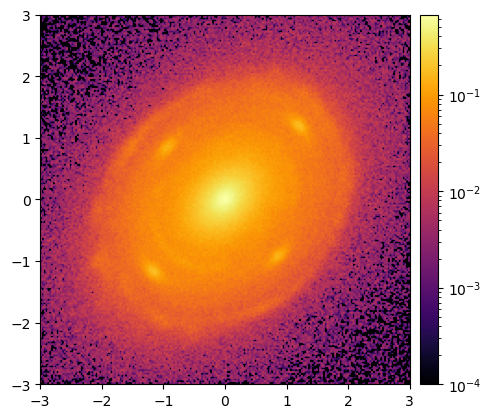

In [33]:
# img = sim_lens
dx = sim_config.delta_pix
n = sim_config.num_pix
dim = dx*n
extent = [-dim/2, dim/2, -dim/2, dim/2,]
fig, ax = plt.gcf(), plt.gca()
# cnorm = matplotlib.colors.LogNorm(vmin=max(img.min(), 1e0), vmax=img.max(), clip=True)
# cmap = 'inferno'
# ax.imshow(img, extent=extent)#,cmap=cmap, norm=cnorm)
plot_image(fig, ax, sim_lens_noised, extent=extent, remove_axis=False, log_vmin=1e-4)
# add_caustics(ax, true_params, sim_config, lens_objects=['EPL', 'TNFW_ELLIPSE_POTENTIAL', 'SHEAR'])
# ax.plot(halo_x, halo_y, "r*", markersize=3, label="Halo Location")
# ax.set_title(f"Lensing system halo added")
# ax.legend()
# ax.imshow(sim_lens_noised, extent=extent)
plt.show()

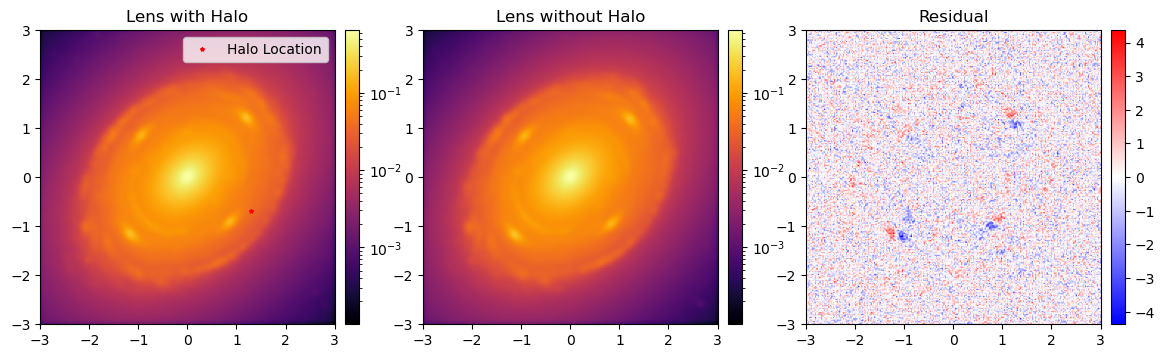

In [34]:
# img = sim_lens
dx = sim_config.delta_pix
n = sim_config.num_pix
dim = dx*n
extent = [-dim/2, dim/2, -dim/2, dim/2,]
fig, (ax1, ax2, ax3) = plt.subplots(1, 3)
fig.set_size_inches(14, 4)
# cnorm = matplotlib.colors.LogNorm(vmin=max(img.min(), 1e0), vmax=img.max(), clip=True)
# cmap = 'inferno'
# ax.imshow(img, extent=extent)#,cmap=cmap, norm=cnorm)
vmin = 1e-8
plot_image(fig, ax1, sim_lens, extent=extent, remove_axis=False, title="Lens with Halo", log_vmin=vmin)
plot_image(fig, ax2, sim_lens_no_halo, extent=extent, remove_axis=False, title="Lens without Halo", log_vmin=vmin)
plot_image(fig, ax3, (sim_lens_noised-sim_lens_no_halo)/noise_map, extent=extent, remove_axis=False, title="Residual", residual=True)
# add_caustics(ax, true_params, sim_config, lens_objects=['EPL', 'TNFW_ELLIPSE_POTENTIAL', 'SHEAR'])
ax1.plot(halo_x, halo_y, "r*", markersize=3, label="Halo Location")
# ax.set_title(f"Lensing system halo added")
ax1.legend()
plt.show()